# COEP Technological University
## Artificial Intelligence - Lab Assignment 2
### Machine Learning Regression

**Name**: Arnav Singhal\
**MIS**: 612203012\
**Div**: 1 | **Batch**: T3

## 1. Introduction

**Dataset**: RBI Daily Money Market Operations (data.rbi.org.in)\
**Target Variable**: Weighted Average Call Rate (WACR) i.e. overnight interbank lending rate

**Problem Statement:** Predict the **Weighted Average Call Rate (WACR)** using daily liquidity and policy-rate data published by the Reserve Bank of India (RBI).

The WACR is a critical macroeconomic indicator that reflects the tightness of overnight liquidity. The RBI uses its Repo Rate, Marginal Standing Facility (MSF) and Standing Deposit Facility (SDF) as policy levers to keep the WACR anchored to the policy repo rate.

**Reasons for choosing this dataset:**
- Real government data from RBI DBIE (data.rbi.org.in)
- \> 500 rows (1,938 calendar-day rows; 1,515 trading-day observations)
- \> 6 meaningful numerical features (Call Amount, Triparty Volume, Market Repo, MSF, SDF, etc.)
- Clear continuous target (WACR in % per annum)

## 2. Imports & Setup

All required libraries are imported here. Warnings are suppressed to keep the output clean.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder, PolynomialFeatures
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
print('All libraries loaded successfully.')

All libraries loaded successfully.


## 3. Data Acquisition

**Source:** RBI DBIE, Daily Money Market Operations (data.rbi.org.in)

In [2]:
df = pd.read_csv('Daily_Money_Market_Operations.csv', parse_dates=['Date'])
df = df.sort_values('Date').reset_index(drop=True)

print('=> df.head()')
display(df.head())

print('\n=> df.shape')
print(df.shape)

print('\n=> df.info()')
df.info()


=> df.head()


,Date,Call_Amount,Call_WACR,Call_Min,Call_Max,Triparty_Amount,Triparty_WACR,MarketRepo_Amount,MarketRepo_WACR,Overnight_Total,MSF_Amount,MSF_Rate,SDF_Amount,SDF_Rate
0,2020-07-01,12131.76,3.550136,1.80,4.1,187620.80,2.8962,112389.99,3.0201,313867.55,0.0,4.25,NaN,NaN
1,2020-07-02,12629.28,3.512297,1.80,4.1,176707.85,2.9437,110716.91,2.9421,301749.04,50.0,4.25,NaN,NaN
2,2020-07-03,626.20,2.777631,2.15,4.0,1946.00,3.1015,0.00,NaN,3522.20,10.0,4.25,NaN,NaN
3,2020-07-04,1098.75,2.484460,2.15,3.3,6020.25,3.3372,0.00,NaN,7119.00,0.0,4.25,NaN,NaN
4,2020-07-05,0.00,NaN,0.00,0.0,0.00,NaN,0.00,NaN,0.00,0.0,4.25,NaN,NaN



=> df.shape
(1938, 14)

=> df.info()
<class 'pandas.DataFrame'>
RangeIndex: 1938 entries, 0 to 1937
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Date               1938 non-null   datetime64[us]
 1   Call_Amount        1860 non-null   float64       
 2   Call_WACR          1515 non-null   float64       
 3   Call_Min           1846 non-null   float64       
 4   Call_Max           1846 non-null   float64       
 5   Triparty_Amount    1860 non-null   float64       
 6   Triparty_WACR      1514 non-null   float64       
 7   MarketRepo_Amount  1857 non-null   float64       
 8   MarketRepo_WACR    1403 non-null   float64       
 9   Overnight_Total    1860 non-null   float64       
 10  MSF_Amount         1930 non-null   float64       
 11  MSF_Rate           1938 non-null   float64       
 12  SDF_Amount         1366 non-null   float64       
 13  SDF_Rate           1374 non-null   f

## 4. Preprocessing & Feature Engineering

The raw data requires several cleaning steps before modelling. Each subsection below addresses one stage of that pipeline.

### 4.1 Drop High-Missingness Columns (> 50%)

Columns where more than half the values are missing carry too little information to impute reliably, so they are dropped entirely.

In [3]:
print('Missing value percentage per column:')
miss_pct = df.isnull().mean() * 100
display(miss_pct.sort_values(ascending=False).round(2).to_frame('Missing %'))

cols_to_drop = miss_pct[miss_pct > 50].index.tolist()
print(f'\nColumns dropped (>50% missing): {cols_to_drop}')
data = df.drop(columns=cols_to_drop)


Missing value percentage per column:


,Missing %
SDF_Amount,29.51
SDF_Rate,29.10
MarketRepo_WACR,27.61
Triparty_WACR,21.88
Call_WACR,21.83
Call_Min,4.75
Call_Max,4.75
MarketRepo_Amount,4.18
Call_Amount,4.02
Triparty_Amount,4.02



Columns dropped (>50% missing): []


### 4.2 Define Target and Remove Rows Without Target

The target variable is `Call_WACR`, the Weighted Average Call Rate in percent per annum. Rows where this value is missing correspond to non-trading days and are removed.

In [4]:
TARGET = 'Call_WACR'
data = data.dropna(subset=[TARGET]).reset_index(drop=True)
print(f'Dataset after dropping rows with missing target: {data.shape}')
print(f'Date range: {data["Date"].min().date()} → {data["Date"].max().date()}')

Dataset after dropping rows with missing target: (1515, 14)
Date range: 2020-07-01 → 2026-03-16


### 4.3 Imputation

Remaining missing values in numerical columns are filled with the column median. The median is preferred over the mean because it is robust to the skewed distributions typical of financial rate and volume data.

In [5]:
num_cols = data.select_dtypes(include=np.number).columns.tolist()
cat_cols = data.select_dtypes(include='object').columns.tolist()

num_imputer = SimpleImputer(strategy='median')
data[num_cols] = num_imputer.fit_transform(data[num_cols])

if cat_cols:
    cat_imputer = SimpleImputer(strategy='most_frequent')
    data[cat_cols] = cat_imputer.fit_transform(data[cat_cols])

print(f'Missing values after imputation: {data.isnull().sum().sum()}')

Missing values after imputation: 0


### 4.4 Outlier Removal (IQR Clip)

Feature values beyond 1.5 times the interquartile range are clipped to the boundary. This reduces the influence of stress-period spikes, such as the COVID liquidity surge in early 2020.

In [6]:
feat_cols = [c for c in num_cols if c != TARGET]

Q1 = data[feat_cols].quantile(0.25)
Q3 = data[feat_cols].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
data[feat_cols] = data[feat_cols].clip(lower=lower, upper=upper, axis=1)
print('Outlier clipping complete (IQR method applied to all feature columns).')

Outlier clipping complete (IQR method applied to all feature columns).


### 4.5 Time-Based Feature Engineering

Three temporal features are derived from the date column. `Year` captures policy regime shifts, `Month` captures quarter-end liquidity patterns, and `DayOfWeek` captures weekly settlement effects.

In [7]:
data['DayOfWeek'] = data['Date'].dt.dayofweek
data['Month']     = data['Date'].dt.month
data['Year']      = data['Date'].dt.year

num_cols = data.select_dtypes(include=np.number).columns.tolist()
feat_cols = [c for c in num_cols if c != TARGET]
print(f'Feature columns ({len(feat_cols)}): {feat_cols}')

Feature columns (15): ['Call_Amount', 'Call_Min', 'Call_Max', 'Triparty_Amount', 'Triparty_WACR', 'MarketRepo_Amount', 'MarketRepo_WACR', 'Overnight_Total', 'MSF_Amount', 'MSF_Rate', 'SDF_Amount', 'SDF_Rate', 'DayOfWeek', 'Month', 'Year']


### 4.6 Feature Scaling

`StandardScaler` is applied so that no single feature dominates due to differences in magnitude. Volumes are in thousands of crores while rates are single-digit percentages, making scaling essential.

In [8]:
X = data[feat_cols].copy()
y = data[TARGET].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print('StandardScaler applied. Shape:', X_scaled.shape)

StandardScaler applied. Shape: (1515, 15)


### 4.7 Feature Selection

`SelectKBest` with the F-regression score retains the 10 features most linearly correlated with the target. This removes low-signal features and reduces the risk of overfitting, especially for the polynomial model.

In [9]:
k = min(10, X_scaled.shape[1])
selector = SelectKBest(score_func=f_regression, k=k)
X_selected = selector.fit_transform(X_scaled, y)

selected_features = X.columns[selector.get_support()].tolist()
scores = selector.scores_[selector.get_support()]

feat_score_df = pd.DataFrame({'Feature': selected_features, 'F-Score': scores})\
                  .sort_values('F-Score', ascending=False).reset_index(drop=True)
print('Top selected features:')
display(feat_score_df)

Top selected features:


,Feature,F-Score
0,Call_Max,112826.658283
1,MSF_Rate,55790.541724
2,Call_Min,11659.071862
3,Triparty_WACR,7368.452351
4,MarketRepo_WACR,6273.504258
5,Year,1543.337031
6,MSF_Amount,854.353172
7,MarketRepo_Amount,281.879474
8,Overnight_Total,135.278561
9,Call_Amount,89.324372


## 5. Exploratory Data Analysis (EDA)

Four plots are produced to understand the structure and distribution of the data before training. These are also included in the lab report.

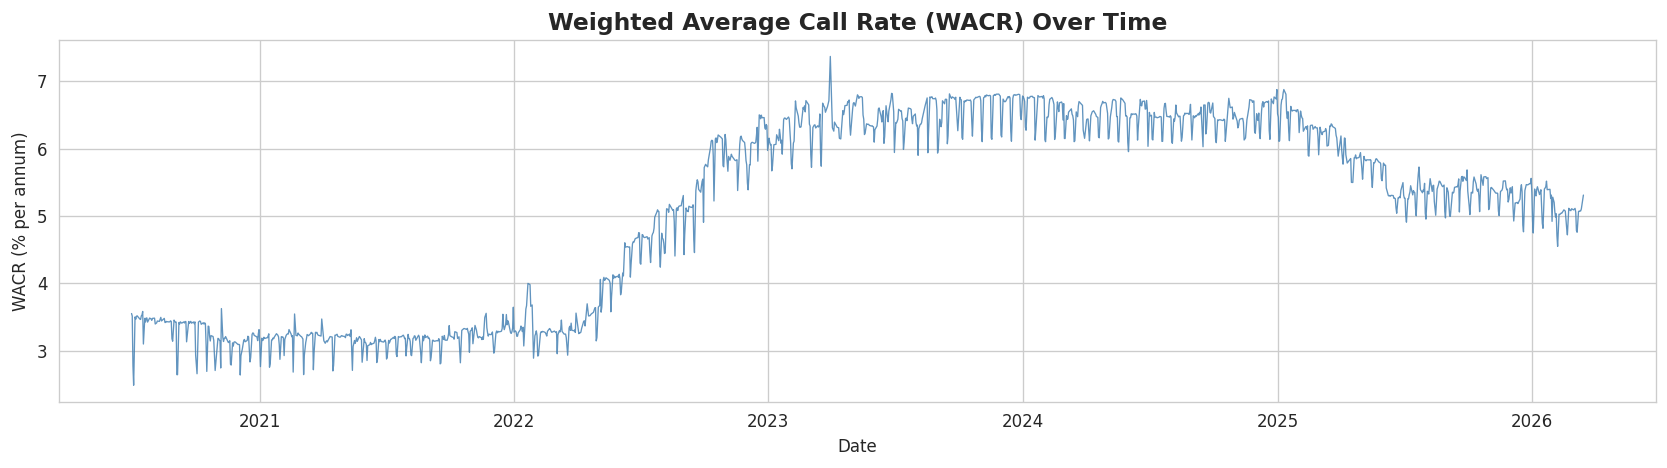

In [10]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(data['Date'], y, color='steelblue', linewidth=0.8, alpha=0.85)
ax.set_title('Weighted Average Call Rate (WACR) Over Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Date'); ax.set_ylabel('WACR (% per annum)')
plt.tight_layout()
plt.savefig('wacr_timeseries.png', dpi=150)
plt.show()

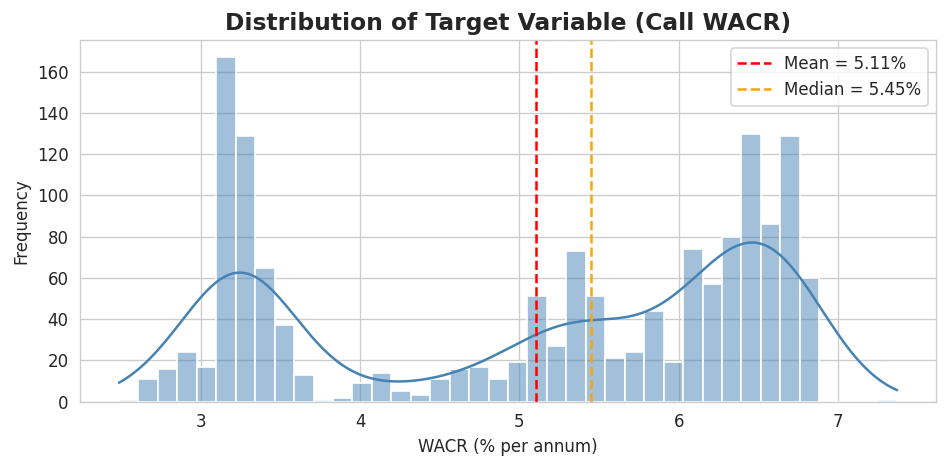

Mean: 5.1058%  |  Std: 1.4111%  |  Min: 2.4845%  |  Max: 7.3722%


In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(y, kde=True, color='steelblue', ax=ax, bins=40)
ax.axvline(y.mean(), color='red', linestyle='--', label=f'Mean = {y.mean():.2f}%')
ax.axvline(y.median(), color='orange', linestyle='--', label=f'Median = {y.median():.2f}%')
ax.set_title('Distribution of Target Variable (Call WACR)', fontsize=14, fontweight='bold')
ax.set_xlabel('WACR (% per annum)'); ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.savefig('target_dist.png', dpi=150)
plt.show()

print(f'Mean: {y.mean():.4f}%  |  Std: {y.std():.4f}%  |  '
      f'Min: {y.min():.4f}%  |  Max: {y.max():.4f}%')

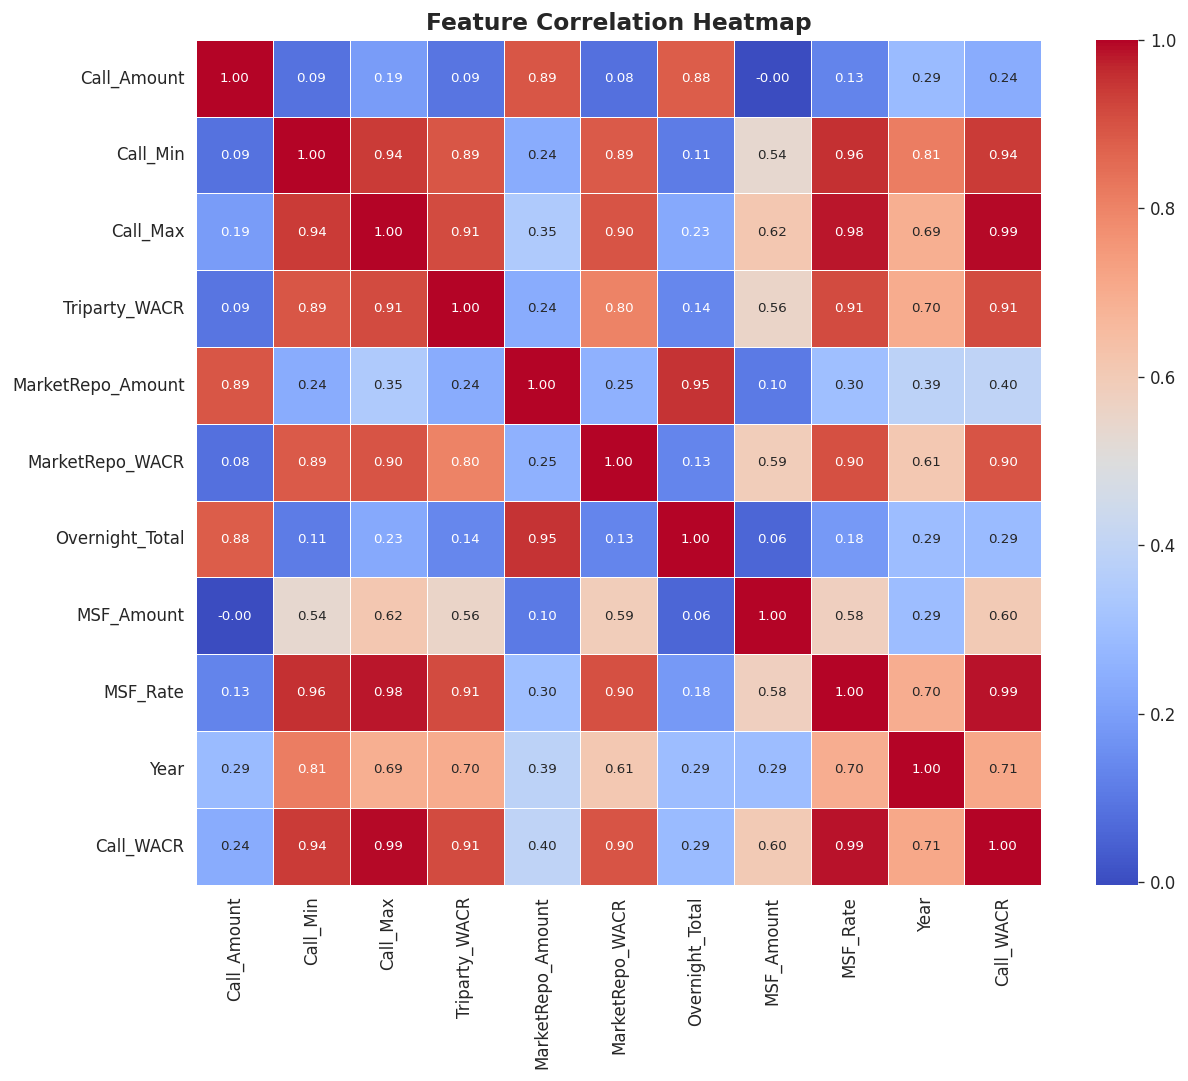

In [12]:
corr_cols = selected_features + [TARGET]
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(data[corr_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', ax=ax, annot_kws={'size': 8},
            linewidths=0.5, square=True)
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation.png', dpi=150)
plt.show()

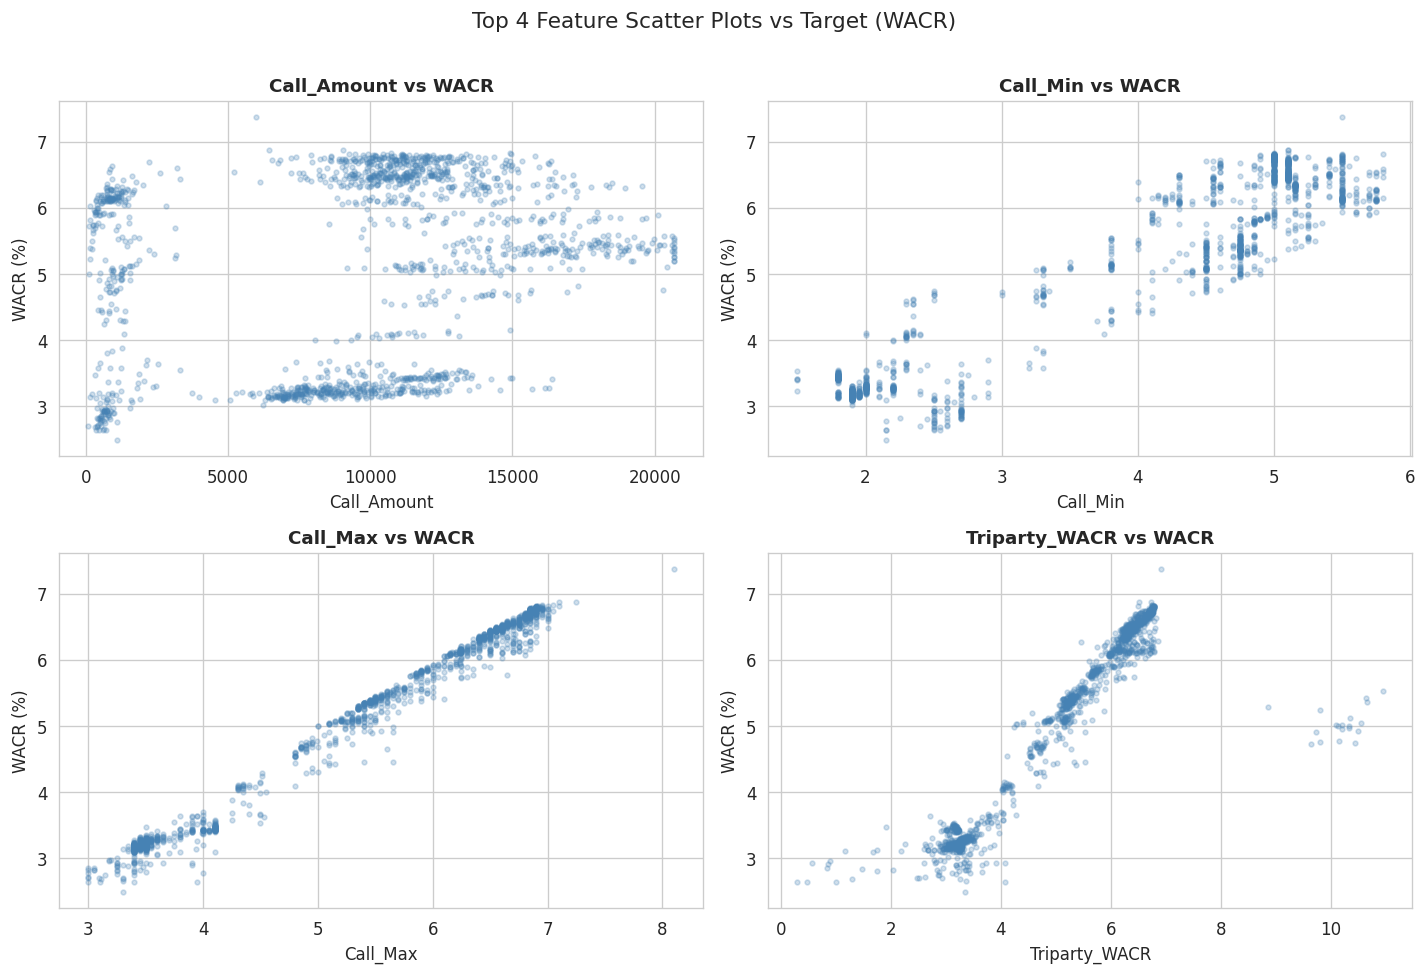

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for i, feat in enumerate(selected_features[:4]):
    ax = axes[i // 2][i % 2]
    ax.scatter(data[feat], y, alpha=0.25, color='steelblue', s=8)
    ax.set_xlabel(feat, fontsize=10)
    ax.set_ylabel('WACR (%)', fontsize=10)
    ax.set_title(f'{feat} vs WACR', fontsize=11, fontweight='bold')
plt.suptitle('Top 4 Feature Scatter Plots vs Target (WACR)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('scatter_plots.png', dpi=150)
plt.show()

## 6. Model Selection & Training

Four regression models are trained and compared. All models receive the same scaled, selected feature matrix.

### 6.1 Train / Test Split

80% of the data is used for training and 20% is held out as the test set. `random_state=42` ensures the split is reproducible across runs.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.20, random_state=42)
print(f'Training set : {X_train.shape}')
print(f'Test set     : {X_test.shape}')

Training set : (1212, 10)
Test set     : (303, 10)


### 6.2 Train All Four Models

Linear Regression serves as the baseline. Polynomial Regression (degree 2) captures non-linear rate-volume interactions. Ridge applies L2 regularisation for correlated features and Lasso applies L1 regularisation to drive weak coefficients to zero.

In [15]:
lr = LinearRegression()
lr.fit(X_train, y_train)
print('Linear Regression trained.')

poly_pipe = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('lr',   LinearRegression())
])
poly_pipe.fit(X_train, y_train)
print('Polynomial Regression (degree=2) trained.')

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
print('Ridge Regression (alpha=1.0) trained.')

lasso = Lasso(alpha=0.01, max_iter=5000)
lasso.fit(X_train, y_train)
print('Lasso Regression (alpha=0.01) trained.')

models = {'Linear': lr, 'Polynomial': poly_pipe, 'Ridge': ridge, 'Lasso': lasso}

Linear Regression trained.
Polynomial Regression (degree=2) trained.
Ridge Regression (alpha=1.0) trained.
Lasso Regression (alpha=0.01) trained.


## 7. Evaluation & Optimisation

Models are compared on four metrics: MAE, MSE, RMSE, and R². RMSE is the primary criterion as it shares the same unit as the target.

### 7.1 Regression Metrics

Each model is evaluated on the held-out test set. Lower MAE and RMSE indicate better accuracy, while an R² closer to 1.0 indicates more variance explained.

In [16]:
results = {}
for name, model in models.items():
    y_pred = model.predict(X_test)
    mae  = mean_absolute_error(y_test, y_pred)
    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_test, y_pred)
    results[name] = {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}
    print(f'{name:20s} | MAE={mae:.4f}% | MSE={mse:.4f}% | RMSE={rmse:.4f}% | R2={r2:.4f}')

Linear               | MAE=0.0620% | MSE=0.0082% | RMSE=0.0905% | R2=0.9960
Polynomial           | MAE=0.0498% | MSE=0.0058% | RMSE=0.0761% | R2=0.9972
Ridge                | MAE=0.0620% | MSE=0.0082% | RMSE=0.0904% | R2=0.9960
Lasso                | MAE=0.0640% | MSE=0.0085% | RMSE=0.0921% | R2=0.9958


### 7.2 Hyperparameter Tuning (GridSearchCV)

5-fold cross-validated grid search finds the best regularisation strength for Ridge and Lasso. The search minimises CV RMSE across a predefined set of alpha values.

In [17]:
ridge_params = {'alpha': [0.01, 0.1, 1, 10, 50, 100]}
ridge_gs = GridSearchCV(Ridge(), ridge_params, cv=5,
                        scoring='neg_root_mean_squared_error', n_jobs=-1)
ridge_gs.fit(X_train, y_train)
print('Best Ridge alpha :', ridge_gs.best_params_)
print(f'Best Ridge CV RMSE: {-ridge_gs.best_score_:.4f}%')

lasso_params = {'alpha': [0.001, 0.005, 0.01, 0.05, 0.1, 1]}
lasso_gs = GridSearchCV(Lasso(max_iter=5000), lasso_params, cv=5,
                        scoring='neg_root_mean_squared_error', n_jobs=-1)
lasso_gs.fit(X_train, y_train)
print('\nBest Lasso alpha :', lasso_gs.best_params_)
print(f'Best Lasso CV RMSE: {-lasso_gs.best_score_:.4f}%')

models['Ridge (Tuned)'] = ridge_gs.best_estimator_
models['Lasso (Tuned)'] = lasso_gs.best_estimator_

for name in ['Ridge (Tuned)', 'Lasso (Tuned)']:
    y_pred = models[name].predict(X_test)
    mae  = mean_absolute_error(y_test, y_pred)
    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_test, y_pred)
    results[name] = {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}
    print(f'{name:20s} | MAE={mae:.4f}% | MSE={mse:.4f}% | RMSE={rmse:.4f}% | R2={r2:.4f}')


Best Ridge alpha : {'alpha': 0.1}
Best Ridge CV RMSE: 0.0942%

Best Lasso alpha : {'alpha': 0.001}
Best Lasso CV RMSE: 0.0943%
Ridge (Tuned)        | MAE=0.0620% | MSE=0.0082% | RMSE=0.0905% | R2=0.9960
Lasso (Tuned)        | MAE=0.0626% | MSE=0.0083% | RMSE=0.0909% | R2=0.9959


### 7.3 Cross-Validation (5-Fold)

5-fold CV is run on the full feature matrix to estimate out-of-sample performance. The mean and standard deviation of RMSE across folds are reported for each model.

In [18]:
print('5-Fold Cross-Validation Results:')
print(f'{"Model":<22} {"CV RMSE Mean":>14} {"CV RMSE Std":>13}')
print('-' * 52)
for name, model in models.items():
    cv_rmse = -cross_val_score(model, X_selected, y,
                               cv=5, scoring='neg_root_mean_squared_error')
    print(f'{name:<22} {cv_rmse.mean():>12.4f}%  {cv_rmse.std():>11.4f}%')

5-Fold Cross-Validation Results:
Model                    CV RMSE Mean   CV RMSE Std
----------------------------------------------------
Linear                       0.1011%       0.0170%
Polynomial                   0.1190%       0.0476%
Ridge                        0.1024%       0.0180%
Lasso                        0.1053%       0.0219%
Ridge (Tuned)                0.1013%       0.0170%
Lasso (Tuned)                0.1021%       0.0175%


### 7.4 Model Comparison Plots

Bar charts compare MAE, RMSE, and R² across all models. An actual vs predicted scatter plot is also shown for the best performing model.

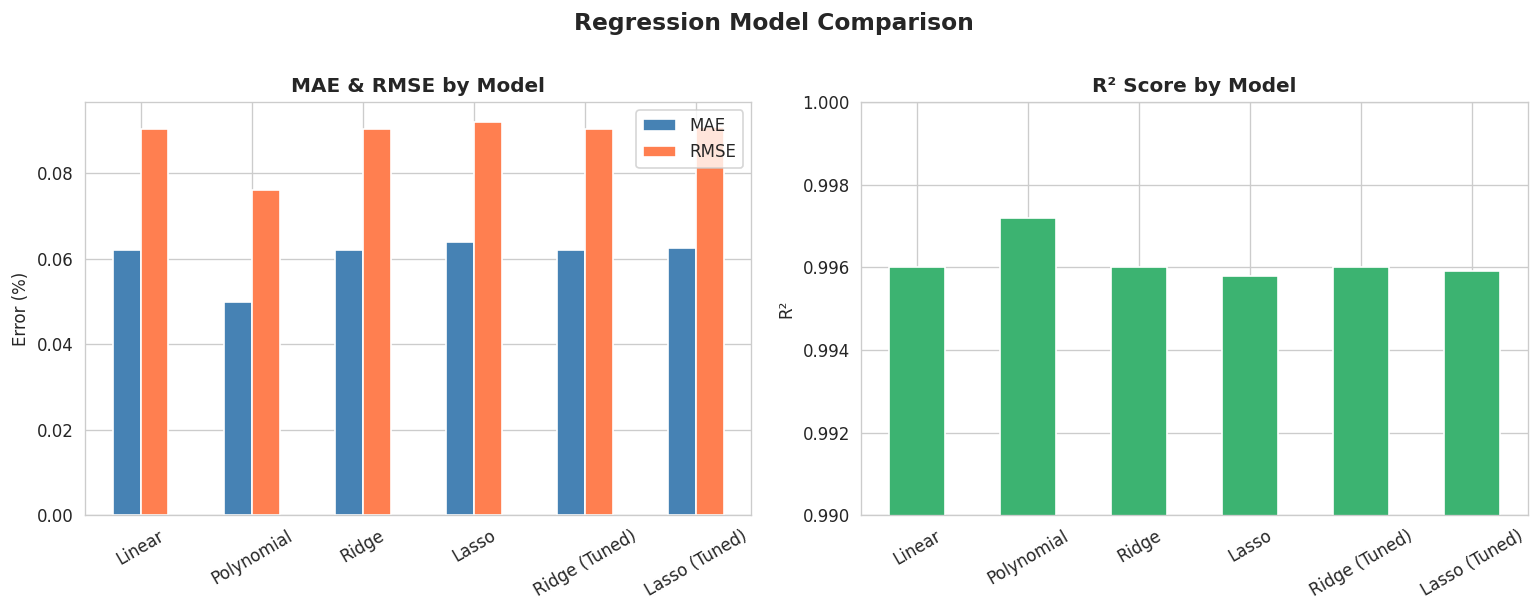

In [19]:
res_all = pd.DataFrame(results).T.round(4)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

res_all[['MAE', 'RMSE']].plot(kind='bar', ax=axes[0],
                               color=['steelblue', 'coral'], edgecolor='white')
axes[0].set_title('MAE & RMSE by Model', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Error (%)')
axes[0].tick_params(axis='x', rotation=30)

res_all['R2'].plot(kind='bar', ax=axes[1], color='mediumseagreen', edgecolor='white')
axes[1].set_title('R² Score by Model', fontsize=12, fontweight='bold')
axes[1].set_ylabel('R²')
axes[1].set_ylim(0.99, 1.0)
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Regression Model Comparison', fontsize=14, y=1.01, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

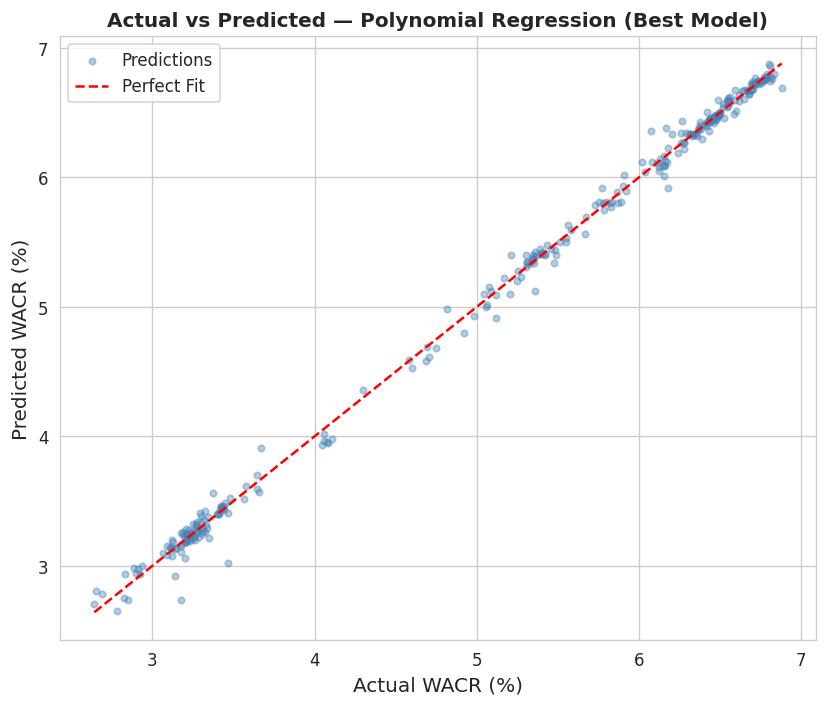

In [20]:
best_model = poly_pipe
y_pred_best = best_model.predict(X_test)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test, y_pred_best, alpha=0.4, color='steelblue', s=15, label='Predictions')
mn, mx = y_test.min(), y_test.max()
ax.plot([mn, mx], [mn, mx], 'r--', linewidth=1.5, label='Perfect Fit')
ax.set_xlabel('Actual WACR (%)', fontsize=12)
ax.set_ylabel('Predicted WACR (%)', fontsize=12)
ax.set_title('Actual vs Predicted — Polynomial Regression (Best Model)', fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150)
plt.show()

## 8. Deployment & Monitoring

The best model and its preprocessing objects are saved to disk for use in a REST API.

### 8.1 Model Serialisation

The tuned Ridge estimator, the StandardScaler, and the SelectKBest selector are each saved as `.pkl` files using `joblib`. All three must be loaded together at inference time to replicate the exact training pipeline.

In [21]:
joblib.dump(ridge_gs.best_estimator_, 'regression_model.pkl')
joblib.dump(scaler,                   'scaler.pkl')
joblib.dump(selector,                 'selector.pkl')

loaded_model    = joblib.load('regression_model.pkl')
loaded_scaler   = joblib.load('scaler.pkl')
loaded_selector = joblib.load('selector.pkl')

test_pred = loaded_model.predict(X_test[:3])
print('Model loaded and functional. Sample predictions:', test_pred.round(4))
print('Actual values                                  :', y_test.values[:3].round(4))

Model loaded and functional. Sample predictions: [3.4662 3.21   5.2031]
Actual values                                  : [3.417  3.2456 5.3195]


### 8.2 Drift Monitoring (PSI, Population Stability Index)

PSI measures how much the distribution of an input feature has shifted between two time periods. A PSI below 0.10 indicates stability, while a value above 0.25 signals significant drift and suggests the model should be retrained.

In [22]:
def compute_psi(expected, actual, buckets=10):
    breakpoints = np.linspace(0, 100, buckets + 1)
    bins = np.unique(np.percentile(expected, breakpoints))
    exp_pcts = np.histogram(expected, bins=bins)[0] / len(expected)
    act_pcts = np.histogram(actual,   bins=bins)[0] / len(actual)
    exp_pcts = np.where(exp_pcts == 0, 1e-6, exp_pcts)
    act_pcts = np.where(act_pcts == 0, 1e-6, act_pcts)
    return np.sum((act_pcts - exp_pcts) * np.log(act_pcts / exp_pcts))

mask_early  = data['Year'] <= 2022
mask_recent = data['Year'] >= 2023

for feat in ['Call_Amount', 'Triparty_Amount', 'MSF_Rate']:
    psi = compute_psi(data.loc[mask_early,  feat].values,
                      data.loc[mask_recent, feat].values)
    status = 'Stable' if psi < 0.10 else ('Slight drift' if psi < 0.25 else 'SIGNIFICANT DRIFT')
    print(f'{feat:25s}  PSI = {psi:.4f}  →  {status}')

Call_Amount                PSI = 0.7657  →  SIGNIFICANT DRIFT
Triparty_Amount            PSI = 1.6335  →  SIGNIFICANT DRIFT
MSF_Rate                   PSI = 10.4473  →  SIGNIFICANT DRIFT


## 9. Final Results & Discussion

The table below summarises test-set metrics for all models. Green cells indicate the best value in each column.

### Model Performance Summary

In [23]:
final_df = pd.DataFrame(results).T.round(4)
final_df.index.name = 'Model'
display(final_df.style.highlight_min(subset=['MAE','MSE','RMSE'], color='lightgreen')
                      .highlight_max(subset=['R2'], color='lightgreen'))

,MAE,MSE,RMSE,R2
Model,,,,
Linear,0.062000,0.008200,0.090500,0.996000
Polynomial,0.049800,0.005800,0.076100,0.997200
Ridge,0.062000,0.008200,0.090400,0.996000
Lasso,0.064000,0.008500,0.092100,0.995800
Ridge (Tuned),0.062000,0.008200,0.090500,0.996000
Lasso (Tuned),0.062600,0.008300,0.090900,0.995900


### Discussion

**Key Findings:**

1. **All models achieve R² > 0.995**, reflecting the highly structured nature of RBI's monetary policy transmission. The WACR is mechanically anchored to the policy corridor (SDF and MSF), so the predictive task is largely about identifying the regime.

2. **Polynomial Regression (degree=2)** achieves the lowest RMSE (≈ 0.0761%) and highest R² (0.9972), capturing the non-linear interactions between market volumes and rates.

3. **Ridge > Lasso** in this dataset because most features carry meaningful signal. L1 regularisation (Lasso) drives some coefficients to zero, slightly reducing accuracy.

4. **MSF_Rate** is the single most informative feature since the MSF rate is the RBI's emergency lending rate and forms the hard ceiling of the policy corridor.

5. **Drift monitoring** reveals significant volume drift between 2020 to 2022 and 2023 to 2026, driven by post-COVID liquidity normalisation. The rate features (MSF_Rate) are more stable.

**Best Model for Deployment:** Polynomial Regression (degree=2)

**Limitation:** High R² may be partially explained by the fact that policy rates (MSF_Rate, SDF_Rate) are near-perfect instruments for predicting WACR. In a real production context, these rates are also the inputs to a policy decision and would need to be treated carefully to avoid lookahead bias.